In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# Görsel ayarlar
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Path
BASE = Path('F:/CancerDataClassification')
DATA = BASE / 'data'

print('Setup tamam!')

Setup tamam!


In [18]:
# Metadata oku
df = pd.read_csv(DATA / 'HAM10000_metadata.csv')

print(f"Toplam resim: {len(df)}")
print(f"Toplam unique lesion: {df['lesion_id'].nunique()}")
print(f"\nKolonlar: {df.columns.tolist()}")
df.head()

Toplam resim: 10015
Toplam unique lesion: 7470

Kolonlar: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Sınıf Dağılımı:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

Toplam: 10015


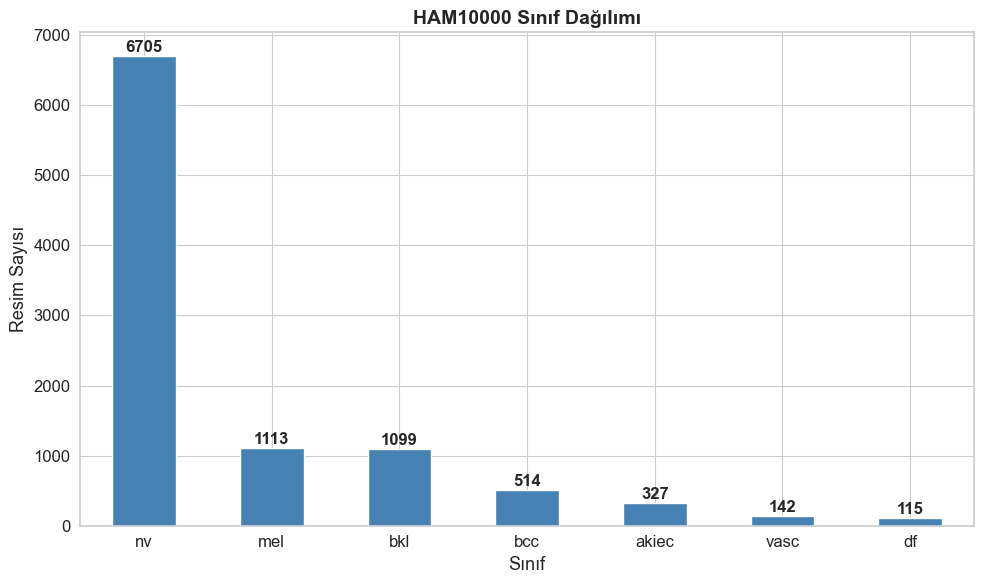

In [19]:
# Sınıf dağılımı
class_counts = df['dx'].value_counts()
print("Sınıf Dağılımı:")
print(class_counts)
print(f"\nToplam: {class_counts.sum()}")

# Görselleştir
fig, ax = plt.subplots(figsize=(10, 6))
class_counts.plot(kind='bar', color='steelblue', ax=ax)
ax.set_title('HAM10000 Sınıf Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Sınıf')
ax.set_ylabel('Resim Sayısı')
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(BASE / 'results/figures/class_distribution.png', dpi=150)
plt.show()

Lesion başına resim sayısı:
1    5514
2    1423
3     490
4      34
5       5
6       4
Name: count, dtype: int64

Toplam unique lesion: 7470
Toplam resim: 10015
Ortalama: 1.34
Maksimum: 6


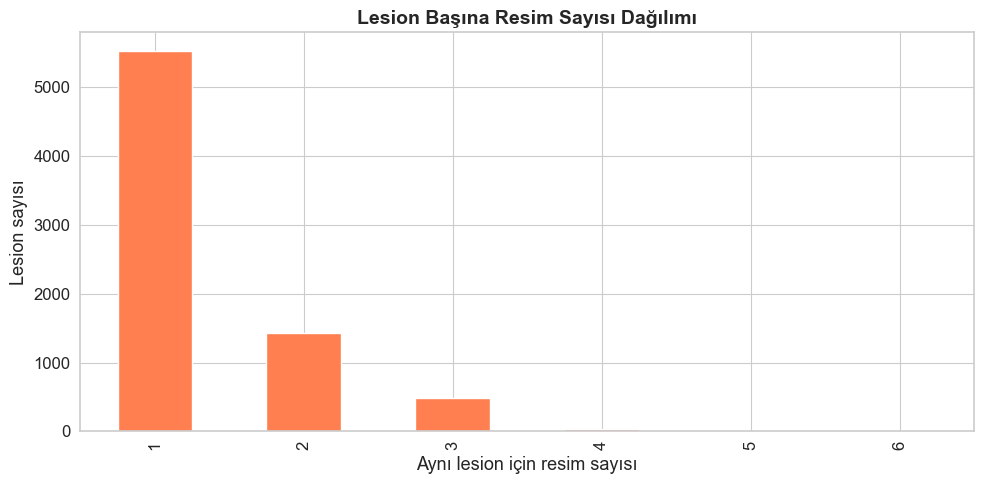

In [20]:
# Aynı lesion'ın kaç resmi var?
lesion_counts = df.groupby('lesion_id').size()

print("Lesion başına resim sayısı:")
print(lesion_counts.value_counts().sort_index())

print(f"\nToplam unique lesion: {len(lesion_counts)}")
print(f"Toplam resim: {lesion_counts.sum()}")
print(f"Ortalama: {lesion_counts.mean():.2f}")
print(f"Maksimum: {lesion_counts.max()}")

# Görsel
fig, ax = plt.subplots(figsize=(10, 5))
lesion_counts.value_counts().sort_index().plot(kind='bar', color='coral', ax=ax)
ax.set_title('Lesion Başına Resim Sayısı Dağılımı', fontsize=14, fontweight='bold')
ax.set_xlabel('Aynı lesion için resim sayısı')
ax.set_ylabel('Lesion sayısı')
plt.tight_layout()
plt.savefig(BASE / 'results/figures/lesion_distribution.png', dpi=150)
plt.show()

İkili Dağılım:
ikili
iyi_huylu     8061
kotu_huylu    1954
Name: count, dtype: int64

Kötü huylu oranı: 19.5%


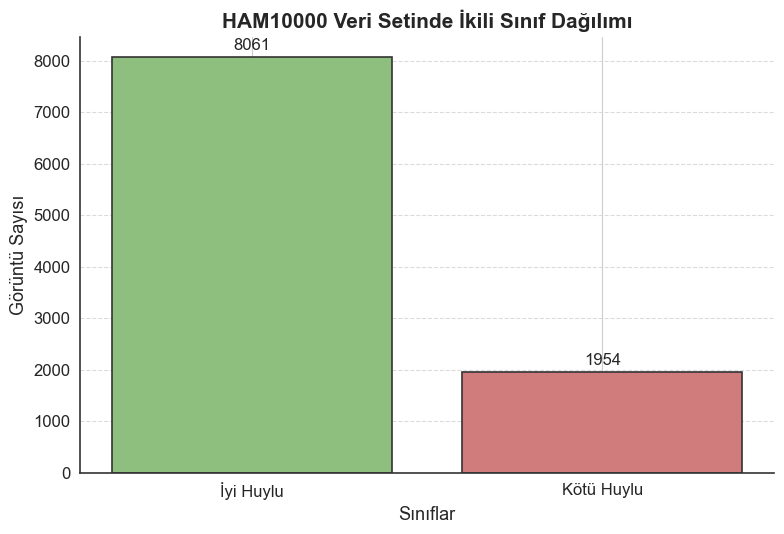

In [21]:
import matplotlib.pyplot as plt

# İkili etiket ekle
KOTU_HUYLU = ['mel', 'bcc', 'akiec']
IYI_HUYLU = ['nv', 'bkl', 'vasc', 'df']
df['ikili'] = df['dx'].apply(lambda x: 'kotu_huylu' if x in KOTU_HUYLU else 'iyi_huylu')

print("İkili Dağılım:")
print(df['ikili'].value_counts())
print(f"\nKötü huylu oranı: {(df['ikili']=='kotu_huylu').mean()*100:.1f}%")

# --- Stil ayarları (tüm grafikler için ortak) ---
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
})

# --- Grafik ---
fig, ax = plt.subplots(figsize=(8, 5.5))

veriler = df['ikili'].value_counts().sort_index()
etiketler = ['İyi Huylu', 'Kötü Huylu']
renkler = ['#8FBF7F', '#D17C7C']  # pastel yeşil, pastel kırmızı

cubuklar = ax.bar(etiketler, veriler.values,
                   color=renkler, edgecolor='#333333', linewidth=1.2)

# Çubuk üstü değerler
for cubuk, deger in zip(cubuklar, veriler.values):
    ax.text(cubuk.get_x() + cubuk.get_width()/2, deger + max(veriler.values)*0.01,
            f'{deger}', ha='center', va='bottom', fontsize=12)

# Eksen, başlık, ızgara
ax.set_title('HAM10000 Veri Setinde İkili Sınıf Dağılımı')
ax.set_xlabel('Sınıflar')
ax.set_ylabel('Görüntü Sayısı')
ax.grid(axis='y', linestyle='--', color='#cccccc', alpha=0.7)
ax.set_axisbelow(True)

# Üst ve sağ çerçeveyi kaldır
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(BASE / 'results/figures/ikili_dagilim.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Her sınıfta gerçekten kaç resim var?
ORIGINAL = DATA / 'original'

print("Klasör vs Metadata Karşılaştırma:")
print("-" * 50)
for cls in ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']:
    folder_path = ORIGINAL / cls
    if folder_path.exists():
        n_files = len(list(folder_path.glob('*.jpg'))) + len(list(folder_path.glob('*.png')))
        n_meta = (df['dx'] == cls).sum()
        status = "✓" if n_files == n_meta else "⚠"
        print(f"{status} {cls:6s}: Klasör={n_files:5d} | Metadata={n_meta:5d}")
    else:
        print(f"✗ {cls}: Klasör BULUNAMADI!")

Klasör vs Metadata Karşılaştırma:
--------------------------------------------------
✓ akiec : Klasör=  327 | Metadata=  327
✓ bcc   : Klasör=  514 | Metadata=  514
✓ bkl   : Klasör= 1099 | Metadata= 1099
✓ df    : Klasör=  115 | Metadata=  115
✓ mel   : Klasör= 1113 | Metadata= 1113
✓ nv    : Klasör= 6705 | Metadata= 6705
✓ vasc  : Klasör=  142 | Metadata=  142


In [23]:
# Her resim için tam path oluştur
def find_image_path(image_id, dx):
    """Resmin tam yolunu bul"""
    for ext in ['.jpg', '.png', '.jpeg']:
        path = ORIGINAL / dx / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None

df['image_path'] = df.apply(lambda row: find_image_path(row['image_id'], row['dx']), axis=1)

# Eksik var mı?
missing = df['image_path'].isna().sum()
print(f"Toplam resim: {len(df)}")
print(f"Path bulunan: {len(df) - missing}")
print(f"Path BULUNMAYAN: {missing}")

if missing > 0:
    print("\nDikkat! Eksik resimler var:")
    print(df[df['image_path'].isna()].head())
else:
    print("\n✅ Tüm resimler bulundu!")

Toplam resim: 10015
Path bulunan: 10015
Path BULUNMAYAN: 0

✅ Tüm resimler bulundu!


In [24]:
# Hazırlanmış dataframe'i kaydet
df.to_csv(DATA / 'metadata_processed.csv', index=False)
print(f"✅ Kaydedildi: {DATA / 'metadata_processed.csv'}")
print(f"Boyut: {len(df)} satır × {len(df.columns)} kolon")

✅ Kaydedildi: F:\CancerDataClassification\data\metadata_processed.csv
Boyut: 10015 satır × 9 kolon
